# Week 03 — Determinants və Inverses

**Karpathy prinsipi:** Əvvəl manual implementation, sonra NumPy ilə müqayisə.

**Bugünün məqsədi:**
- 2x2 və 3x3 determinant funksiyalarını sıfırdan yaz
- 2x2 inverse-i sıfırdan yaz
- NumPy ilə nəticələri yoxla
- Determinantın həndəsi mənasını koddla göstər (sahə, orientasiya)
- Singular matrislərin niyə invertible olmadığını anla

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible olsun
np.random.seed(42)

---
## Hissə 1 — Əl ilə 2x2 determinant

Formul: $\det\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc$

**Həndəsi mənası:** Vahid kvadrat bu matrislə paraleloqrama çevrilir. $|ad-bc|$ — paraleloqramın sahəsi. İşarə — orientasiya.

In [2]:
def det2x2(M):
    """2x2 matrisin determinantı.
    
    M: shape (2, 2) numpy array və ya nested list
    return: float
    """
    return M[0][0] * M[1][1] - M[0][1] * M[1][0]

# Test 1: identity
I = [[1, 0], [0, 1]]
print(f"det(I) = {det2x2(I)}  (gözlənti: 1)")

# Test 2: scaling
S = [[2, 0], [0, 3]]
print(f"det(S) = {det2x2(S)}  (gözlənti: 6 — sahə 6x artır)")

det(I) = 1  (gözlənti: 1)
det(S) = 6  (gözlənti: 6 — sahə 6x artır)


---
## Hissə 2 — NumPy ilə müqayisə (5 matris)

Dünən əl ilə hesabladığımız 5 matris üçün hər iki funksiyanı işlədib müqayisə edək.

In [6]:
matrices = {
    "Scaling [[2,0],[0,3]]":    np.array([[2, 0], [0, 3]]),
    "Shear   [[1,2],[3,4]]":    np.array([[1, 2], [3, 4]]),
    "Zero    [[2,4],[1,2]]":    np.array([[2, 4], [1, 2]]),
    "Rotate  [[0,-1],[1,0]]":   np.array([[0, -1], [1, 0]]),
    "Reflect [[1,0],[0,-1]]":   np.array([[1, 0], [0, -1]]),
}

print(f"{'Matris':<28} {'Mənim':>10} {'NumPy':>12} {'Fərq':>10}")
print("-" * 64)
for name, M in matrices.items():
    mine = det2x2(M)
    np_det = np.linalg.det(M)
    diff = abs(mine - np_det)
    print(f"{name:<28} {mine:>10.4f} {np_det:>12.4f} {diff:>10.2e}")

Matris                            Mənim        NumPy       Fərq
----------------------------------------------------------------
Scaling [[2,0],[0,3]]            6.0000       6.0000   0.00e+00
Shear   [[1,2],[3,4]]           -2.0000      -2.0000   4.44e-16
Zero    [[2,4],[1,2]]            0.0000       0.0000   0.00e+00
Rotate  [[0,-1],[1,0]]           1.0000       1.0000   0.00e+00
Reflect [[1,0],[0,-1]]          -1.0000      -1.0000   0.00e+00


**Müşahidə:** Fərq sıfır (və ya 1e-15 ətrafında — bu floating point xətasıdır, real fərq deyil). Funksiyam düz işləyir ✓

**Nəticələrin mənası:**
- `+6` → sahə 6x artır, orientasiya qorunur
- `-2` → sahə 2x artır, **orientasiya çevrilir**
- `0`  → matris müstəvini xəttə sıxır (singular)
- `+1` → saf rotation, sahə dəyişmir
- `-1` → saf reflection, sahə dəyişmir amma yön çevrilir

---
## Hissə 3 — Əl ilə 2x2 inverse

Formul: $A^{-1} = \frac{1}{\det(A)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$

**Diaqonalı dəyiş, anti-diaqonalı mənfi et, det-ə böl.**

In [7]:
def inv2x2(M):
    """2x2 matrisin inverse-i.
    
    Raises ValueError əgər det = 0.
    """
    M = np.array(M, dtype=float)
    d = det2x2(M)
    
    if d == 0:
        raise ValueError("Matris singulardır (det=0), inverse yoxdur")
    
    a, b = M[0]
    c, e = M[1]   # 'd' yuxarıda istifadə olunduğu üçün 'e' yazdım
    
    return (1/d) * np.array([[e, -b], [-c, a]])

# Test: dünənki matris
A = np.array([[2, 1], [1, 3]])
A_inv = inv2x2(A)
print("A =\n", A)
print("\nA^-1 =\n", A_inv)
print("\nGözlənti: [[0.6, -0.2], [-0.2, 0.4]]")

A =
 [[2 1]
 [1 3]]

A^-1 =
 [[ 0.6 -0.2]
 [-0.2  0.4]]

Gözlənti: [[0.6, -0.2], [-0.2, 0.4]]


---
## Hissə 4 — NumPy ilə müqayisə

In [8]:
A_inv_np = np.linalg.inv(A)
print("NumPy A^-1 =\n", A_inv_np)
print("\nFərq (element-wise):\n", A_inv - A_inv_np)
print(f"\nMax fərq: {np.max(np.abs(A_inv - A_inv_np)):.2e}")

NumPy A^-1 =
 [[ 0.6 -0.2]
 [-0.2  0.4]]

Fərq (element-wise):
 [[1.11022302e-16 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00]]

Max fərq: 1.11e-16


---
## Hissə 5 — A · A⁻¹ = I yoxlaması (3 matris)

Inverse-in doğru olub-olmadığını həmişə bu cür yoxlamaq olar.

In [9]:
test_matrices = [
    np.array([[2, 1], [1, 3]]),
    np.array([[4, 7], [2, 6]]),
    np.array([[1, 2], [3, 5]]),
]

for i, M in enumerate(test_matrices, 1):
    M_inv = inv2x2(M)
    product = M @ M_inv
    
    print(f"--- Matris {i} ---")
    print("A =\n", M)
    print("A · A^-1 =\n", np.round(product, 10))   # floating point təmizliyi üçün round
    
    # I-ə yaxındır mı?
    is_identity = np.allclose(product, np.eye(2))
    print(f"Identity-yə bərabər? {is_identity}")
    print()

--- Matris 1 ---
A =
 [[2 1]
 [1 3]]
A · A^-1 =
 [[1. 0.]
 [0. 1.]]
Identity-yə bərabər? True

--- Matris 2 ---
A =
 [[4 7]
 [2 6]]
A · A^-1 =
 [[ 1. -0.]
 [ 0.  1.]]
Identity-yə bərabər? True

--- Matris 3 ---
A =
 [[1 2]
 [3 5]]
A · A^-1 =
 [[1. 0.]
 [0. 1.]]
Identity-yə bərabər? True



**Qeyd:** `np.allclose()` — floating point müqayisəsi üçün düzgün üsuldur. `==` istifadə etmə, çünki `0.9999999999998 != 1` deyə nəticə verə bilər.

**ML-də qarşılaşacaq pattern:** Hər zaman `np.allclose()` istifadə et float müqayisəsi üçün.

---
## Hissə 6 — Singular matris (det = 0)

Lineer asılı sütunları olan matrisə nə baş verir? Exception tutaq və izah edək.

In [10]:
# Dünənki nümunə: 2-ci sütun = 2 × 1-ci sütun
Singular = np.array([[1, 2], [2, 4]])

print("Singular matris:\n", Singular)
print(f"det = {np.linalg.det(Singular):.4f}")
print(f"rank = {np.linalg.matrix_rank(Singular)} (2 yox, 1 olduğu üçün singulardır)")
print()

# 1. Mənim funksiyam — ValueError tutmalıyıq
try:
    inv2x2(Singular)
except ValueError as e:
    print(f"Mənim inv2x2: {e}")

# 2. NumPy — LinAlgError tutmalıyıq
try:
    np.linalg.inv(Singular)
except np.linalg.LinAlgError as e:
    print(f"NumPy:        {e}")

Singular matris:
 [[1 2]
 [2 4]]
det = 0.0000
rank = 1 (2 yox, 1 olduğu üçün singulardır)

Mənim inv2x2: Matris singulardır (det=0), inverse yoxdur
NumPy:        Singular matrix


**İzah:**
- `det = 0` → matris müstəvini bir xəttə sıxır
- İki fərqli giriş eyni çıxışa düşür → informasiya itir
- Geri qaytarmaq fundamental olaraq mümkün deyil → inverse yoxdur

**ML kontekstində nə vaxt rastlaşırsan?**
- Linear regression-da `X^T X` singular olanda (multicollinearity)
- Bu halda **pseudo-inverse** (`np.linalg.pinv`) istifadə olunur
- Yaxud regularization (Ridge regression) əlavə olunur ki, matrisi invertible etsin

---
## Hissə 7 — Determinant və sahə (vizual sübut)

Vahid kvadrat → matrisi tətbiq et → paraleloqram. Paraleloqramın sahəsi = |det|.

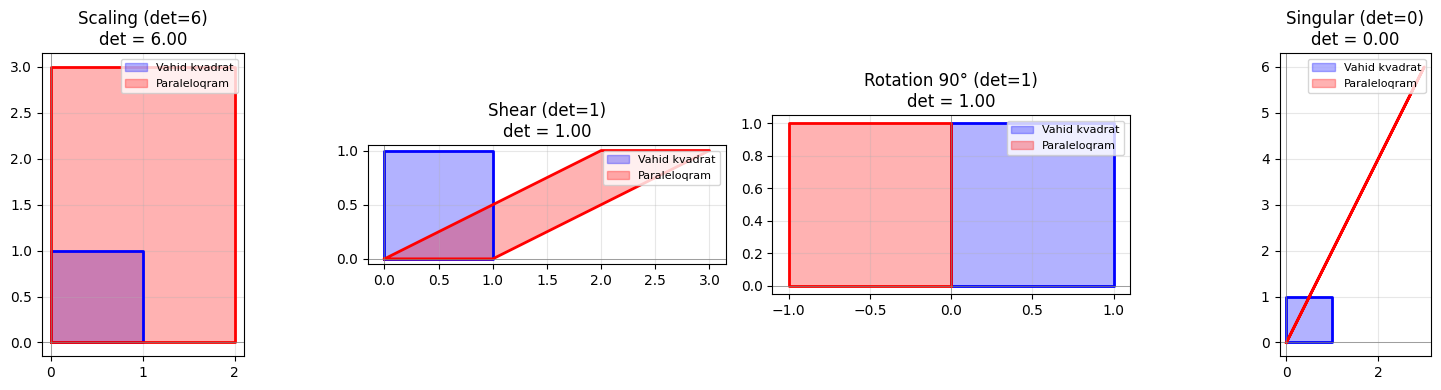

In [11]:
def plot_transformation(M, title, ax):
    """Vahid kvadratı və M-in tətbiqi nəticəsində alınan paraleloqramı çək."""
    # Vahid kvadratın küncləri (sıra ilə, döngəni bağlamaq üçün başlanğıca qayıdır)
    unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T  # shape (2, 5)
    
    # Matrisi tətbiq et
    transformed = M @ unit_square
    
    # Çək
    ax.fill(unit_square[0], unit_square[1], alpha=0.3, color='blue', label='Vahid kvadrat')
    ax.fill(transformed[0], transformed[1], alpha=0.3, color='red', label='Paraleloqram')
    ax.plot(unit_square[0], unit_square[1], 'b-', linewidth=2)
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=2)
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=8)
    
    det = np.linalg.det(M)
    ax.set_title(f"{title}\ndet = {det:.2f}")

# 4 fərqli transformasiya
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plot_transformation(np.array([[2, 0], [0, 3]]), "Scaling (det=6)", axes[0])
plot_transformation(np.array([[1, 2], [0, 1]]), "Shear (det=1)", axes[1])
plot_transformation(np.array([[0, -1], [1, 0]]), "Rotation 90° (det=1)", axes[2])
plot_transformation(np.array([[1, 2], [2, 4]]), "Singular (det=0)", axes[3])

plt.tight_layout()
plt.show()

In [12]:
# Sahəni numerik olaraq hesabla (Shoelace formula) və det ilə müqayisə et
def polygon_area(points):
    """Çoxbucaqlının sahəsi (Shoelace formula).
    points: shape (2, N) — N sayda nöqtənin koordinatları
    """
    x = points[0, :-1]   # son nöqtə təkrardır, atırıq
    y = points[1, :-1]
    return 0.5 * abs(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y))

# Test
M = np.array([[2, 1], [1, 3]])
unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
transformed = M @ unit_square

area = polygon_area(transformed)
det = np.linalg.det(M)

print(f"Paraleloqram sahəsi (Shoelace): {area:.4f}")
print(f"|det(M)|:                       {abs(det):.4f}")
print(f"Bərabərdirlər? {np.isclose(area, abs(det))}")

Paraleloqram sahəsi (Shoelace): 5.0000
|det(M)|:                       5.0000
Bərabərdirlər? True


**Sübut:** Determinant həqiqətən sahənin böyüməsini ölçür ✓

Bu, abstrakt formulun konkret həndəsi mənasını koddla göstərir.

---
## Hissə 8 — Mənfi det (orientasiya çevrilməsi)

Reflection matrisi tətbiq edəndə hərflərin sırası dəyişməlidir.

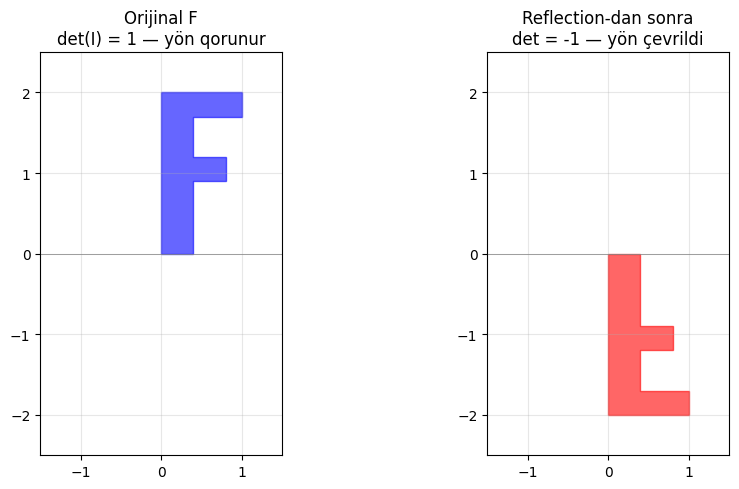

F güzgüdə əks olundu — sahə eyni qaldı (|det|=1), amma orientasiya çevrildi (det<0)


In [13]:
# 'F' hərfini çəkək — asimmetrik olduğu üçün reflection görünəcək
F = np.array([
    [0, 0, 1, 1, 0.4, 0.4, 0.8, 0.8, 0.4, 0.4, 0],
    [0, 2, 2, 1.7, 1.7, 1.2, 1.2, 0.9, 0.9, 0, 0]
])

# Reflection (x oxu üzrə): y → -y
Reflect = np.array([[1, 0], [0, -1]])
F_reflected = Reflect @ F

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].fill(F[0], F[1], color='blue', alpha=0.6)
axes[0].set_title(f"Orijinal F\ndet(I) = 1 — yön qorunur")
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-2.5, 2.5)

axes[1].fill(F_reflected[0], F_reflected[1], color='red', alpha=0.6)
axes[1].set_title(f"Reflection-dan sonra\ndet = {np.linalg.det(Reflect):.0f} — yön çevrildi")
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

print("F güzgüdə əks olundu — sahə eyni qaldı (|det|=1), amma orientasiya çevrildi (det<0)")

**ML kontekstində:** Convolutional neural networks və data augmentation-da reflection (flip) tez-tez istifadə olunur. Mənfi det o deməkdir ki, transformation "chirality"-ni dəyişir.

**3D-də:** Robotics və computer graphics-də mənfi det olan matris istifadə etsən, sağ əli sol əlinə çevirə bilərsən — bu çox vacib məqamdır.

---
## Hissə 9 — 3x3 determinant və həcm

2D-də det = sahə. 3D-də det = **həcm**.

In [17]:
# Dünənki matrislər
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 10]
])

B = np.array([
    [2, 0, 1],
    [3, 1, 2],
    [1, 0, 4]
])

print(f"det(A) = {np.linalg.det(A):.4f}")
print(f"det(B) = {np.linalg.det(B):.4f})")

det(A) = -3.0000
det(B) = 7.0000)


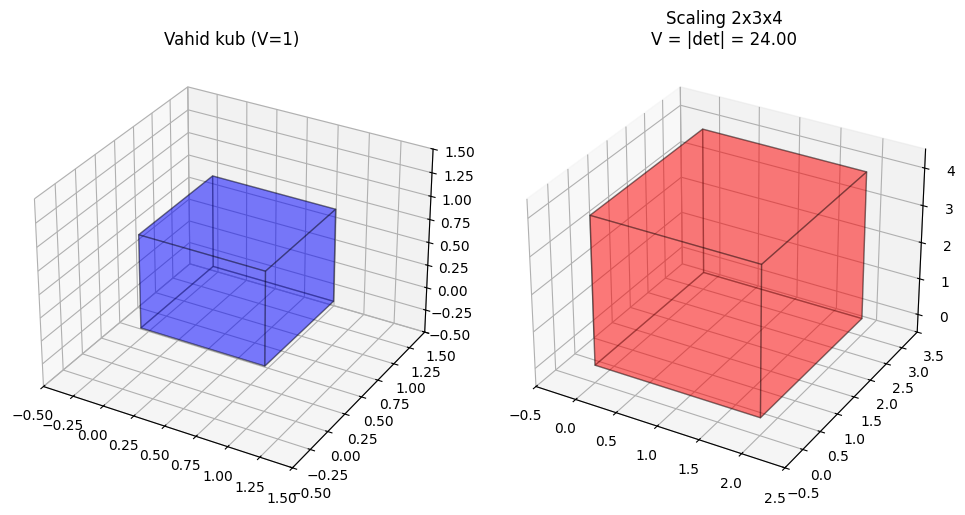

In [18]:
# 3D vizualizasiya — vahid kub paralelepipedə çevrilir
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_3d_transformation(M, title):
    # Vahid kubun 8 təpəsi
    cube_vertices = np.array([
        [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
        [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]
    ]).T
    
    transformed = M @ cube_vertices
    
    fig = plt.figure(figsize=(10, 5))
    
    # Orijinal kub
    ax1 = fig.add_subplot(121, projection='3d')
    plot_cube(ax1, cube_vertices, 'blue', "Vahid kub (V=1)")
    
    # Transformasiya olunmuş
    ax2 = fig.add_subplot(122, projection='3d')
    det = np.linalg.det(M)
    plot_cube(ax2, transformed, 'red', f"{title}\nV = |det| = {abs(det):.2f}")
    
    plt.tight_layout()
    plt.show()

def plot_cube(ax, vertices, color, title):
    # 6 üzün təpə indeksləri
    faces = [
        [0,1,2,3], [4,5,6,7],   # alt, üst
        [0,1,5,4], [2,3,7,6],   # ön, arxa
        [0,3,7,4], [1,2,6,5]    # sol, sağ
    ]
    
    for face in faces:
        pts = vertices[:, face].T
        poly = Poly3DCollection([pts], alpha=0.3, facecolor=color, edgecolor='black')
        ax.add_collection3d(poly)
    
    ax.set_xlim(vertices[0].min()-0.5, vertices[0].max()+0.5)
    ax.set_ylim(vertices[1].min()-0.5, vertices[1].max()+0.5)
    ax.set_zlim(vertices[2].min()-0.5, vertices[2].max()+0.5)
    ax.set_title(title)

# Sadə bir scaling matrisi (det = 2*3*4 = 24)
Scale3D = np.array([[2, 0, 0], [0, 3, 0], [0, 0, 4]])
plot_3d_transformation(Scale3D, "Scaling 2x3x4")

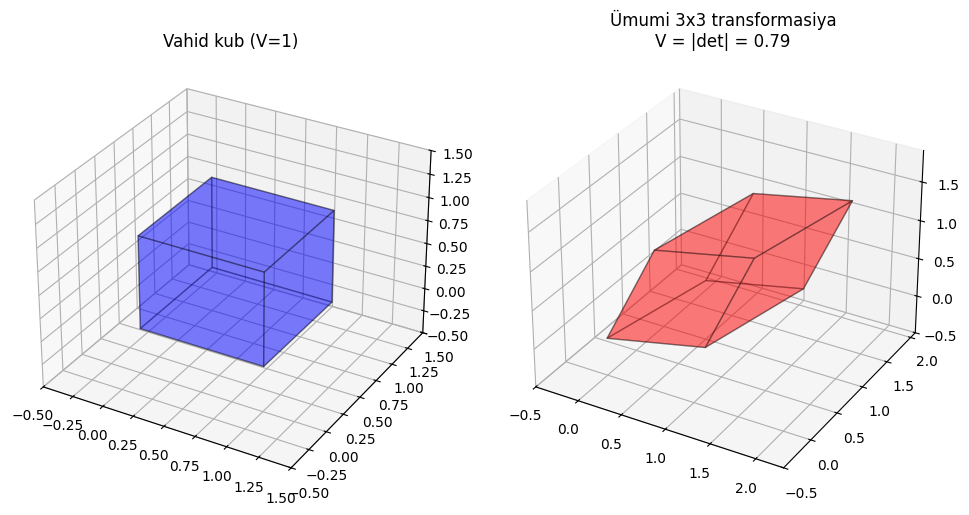

det = 0.7880 — vahid kub bu nisbətdə həcmlə paralelepipedə çevrilir


In [19]:
# Daha ümumi matris
M3 = np.array([
    [1, 0.5, 0.3],
    [0.2, 1, 0.4],
    [0.1, 0.3, 1]
])

plot_3d_transformation(M3, "Ümumi 3x3 transformasiya")
print(f"det = {np.linalg.det(M3):.4f} — vahid kub bu nisbətdə həcmlə paralelepipedə çevrilir")

**Ümumiləşdirmə:**

| Ölçü | det-in mənası |
|------|---------------|
| 2D | Sahənin böyüməsi |
| 3D | Həcmin böyüməsi |
| nD | n-ölçülü "həcmin" böyüməsi |

**İşarə həmişə orientasiyanı (chirality, handedness) göstərir.**

**ML kontekstində bu nə üçün vacibdir?**
- **Change of variables** formulu integrallarda — Jacobian determinantı
- **Normalizing flows** (generative models) — log-determinant istifadə olunur
- **Volume preservation** — invertible neural networks-də

---
## 🎯 Yekun və çıxarışlar

Bu notebook-da nə öyrəndik:

1. **2x2 və 3x3 determinant** — manual implementation və NumPy validation
2. **2x2 inverse** — formul və yoxlama (A·A⁻¹ = I)
3. **Singular matrislər** — niyə invertible deyil (informasiya itir)
4. **Sahə/həcm interpretasiyası** — det sadəcə bir ədəd deyil, həndəsi məna daşıyır
5. **Orientasiya** — mənfi det reflection deməkdir

**Karpathy prinsipi tamamlandı:** Hər funksiyanı əvvəl özümüz yazdıq, sonra NumPy ilə yoxladıq. İndi `np.linalg.det` və `np.linalg.inv` çağıranda **nə baş verdiyini** bilirik.

**Növbəti həftə:** Eigenvectors və eigenvalues — PCA, spectral methods və neural network stabilliyinin əsası.